<a href="https://colab.research.google.com/github/Sherry66410/ML-PROJECT/blob/main/Deployment(LSTM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
df=pd.read_csv("/content/Kerala_Weather.csv",skiprows=17,delimiter=',')

In [ ]:
#Setting the Date Frame's index
df['DATE'] = pd.to_datetime(df[['YEAR', 'MO', 'DY']].astype(str).agg('-'.join, axis=1))
df.set_index('DATE', inplace=True)
df.drop(columns=['YEAR', 'MO', 'DY'], inplace=True)
df.head()


,RH2M,T2M,T2M_MAX,T2M_MIN,WS2M,ALLSKY_SFC_SW_DWN,T2MDEW,PS,PRECTOTCORR
DATE,,,,,,,,,
1981-01-01,71.16,26.07,31.35,21.36,2.11,-999.0,20.08,100.04,0.08
1981-01-02,71.30,26.33,31.44,22.15,1.86,-999.0,20.27,100.06,0.07
1981-01-03,72.93,26.45,31.34,22.03,1.51,-999.0,20.83,100.06,0.09
1981-01-04,73.05,26.13,31.39,21.80,1.71,-999.0,20.47,100.11,2.70
1981-01-05,71.75,25.56,31.08,21.24,1.36,-999.0,19.42,100.21,2.38


In [ ]:
#Taking values ranging from 1st Jan 1981 to 28th Feb 2026
df=df[df.index<="2026-02-28"]
df

,RH2M,T2M,T2M_MAX,T2M_MIN,WS2M,ALLSKY_SFC_SW_DWN,T2MDEW,PS,PRECTOTCORR
DATE,,,,,,,,,
1981-01-01,71.16,26.07,31.35,21.36,2.11,-999.0000,20.08,100.04,0.08
1981-01-02,71.30,26.33,31.44,22.15,1.86,-999.0000,20.27,100.06,0.07
1981-01-03,72.93,26.45,31.34,22.03,1.51,-999.0000,20.83,100.06,0.09
1981-01-04,73.05,26.13,31.39,21.80,1.71,-999.0000,20.47,100.11,2.70
1981-01-05,71.75,25.56,31.08,21.24,1.36,-999.0000,19.42,100.21,2.38
...,...,...,...,...,...,...,...,...,...
2026-02-24,70.04,27.93,33.66,23.94,1.14,5.7701,21.35,98.87,2.66
2026-02-25,72.87,27.43,31.86,25.06,1.15,5.6822,21.89,99.07,3.90
2026-02-26,72.27,26.99,32.34,23.16,1.08,5.7192,21.15,99.00,3.94


In [ ]:
#Replacing all the -999(unlabelled) values with NAN
df.replace(-999.0, np.nan, inplace=True)
df.isnull().sum()

,0
RH2M,3
T2M,3
T2M_MAX,3
T2M_MIN,3
WS2M,3
ALLSKY_SFC_SW_DWN,1095
T2MDEW,3
PS,3
PRECTOTCORR,3


In [ ]:
#Now filling missing values using interpolation since it's a time series data
df.interpolate(method='linear', limit_direction='both', inplace=True)
df.isnull().sum()

,0
RH2M,0
T2M,0
T2M_MAX,0
T2M_MIN,0
WS2M,0
ALLSKY_SFC_SW_DWN,0
T2MDEW,0
PS,0
PRECTOTCORR,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16495 entries, 1981-01-01 to 2026-02-28
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RH2M               16495 non-null  float64
 1   T2M                16495 non-null  float64
 2   T2M_MAX            16495 non-null  float64
 3   T2M_MIN            16495 non-null  float64
 4   WS2M               16495 non-null  float64
 5   ALLSKY_SFC_SW_DWN  16495 non-null  float64
 6   T2MDEW             16495 non-null  float64
 7   PS                 16495 non-null  float64
 8   PRECTOTCORR        16495 non-null  float64
dtypes: float64(9)
memory usage: 1.3 MB


In [ ]:
df.dtypes

,0
RH2M,float64
T2M,float64
T2M_MAX,float64
T2M_MIN,float64
WS2M,float64
ALLSKY_SFC_SW_DWN,float64
T2MDEW,float64
PS,float64
PRECTOTCORR,float64


In [ ]:
df.describe()

,RH2M,T2M,T2M_MAX,T2M_MIN,WS2M,ALLSKY_SFC_SW_DWN,T2MDEW,PS,PRECTOTCORR
count,16495.000000,16495.000000,16495.000000,16495.000000,16495.000000,16495.000000,16495.000000,16495.000000,16495.000000
mean,78.186312,26.864056,30.775413,23.897095,2.149058,5.080593,22.142247,99.931439,5.990141
std,12.483624,1.754680,3.251949,1.761809,0.716527,1.084428,2.645227,0.179893,10.288192
min,31.070000,22.140000,24.760000,16.970000,0.530000,0.645400,6.610000,98.780000,0.000000
25%,68.360000,25.540000,28.140000,23.100000,1.620000,4.479850,21.040000,99.810000,0.030000
50%,82.060000,26.350000,29.810000,23.960000,2.060000,5.175600,23.140000,99.930000,1.480000
75%,88.950000,28.110000,33.270000,25.040000,2.590000,5.862350,23.900000,100.050000,7.480000
max,94.960000,33.020000,39.920000,29.220000,6.040000,7.783400,26.680000,100.510000,175.970000


In [ ]:
#EXPLORATORY DATA ANALYSIS

In [ ]:
#TREND

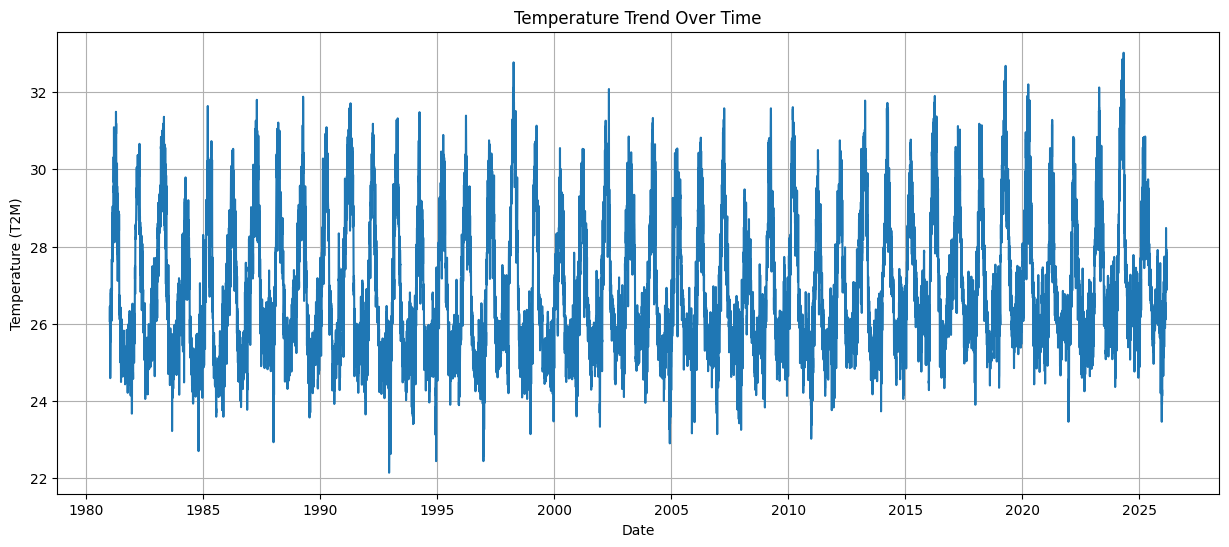

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

plt.figure(figsize=(15, 6))
plt.plot(df['T2M'])
plt.title('Temperature Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (T2M)')
plt.grid(True)
plt.show()

#Trend gives you a macroscopic view of how the temperature has
#behaved throughout the recorded period.We can spot a repeating patterns of
#highs and lows corresponding to warmer and cold months each year



### Seasonality Analysis

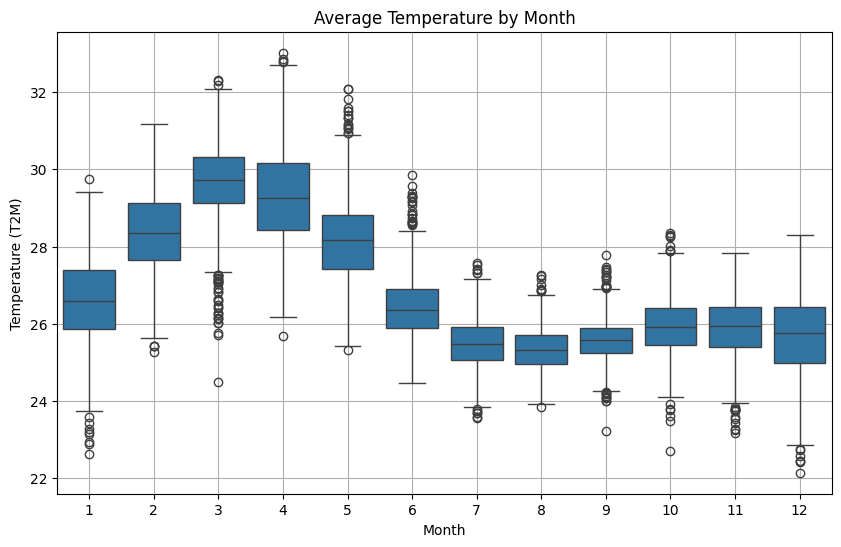

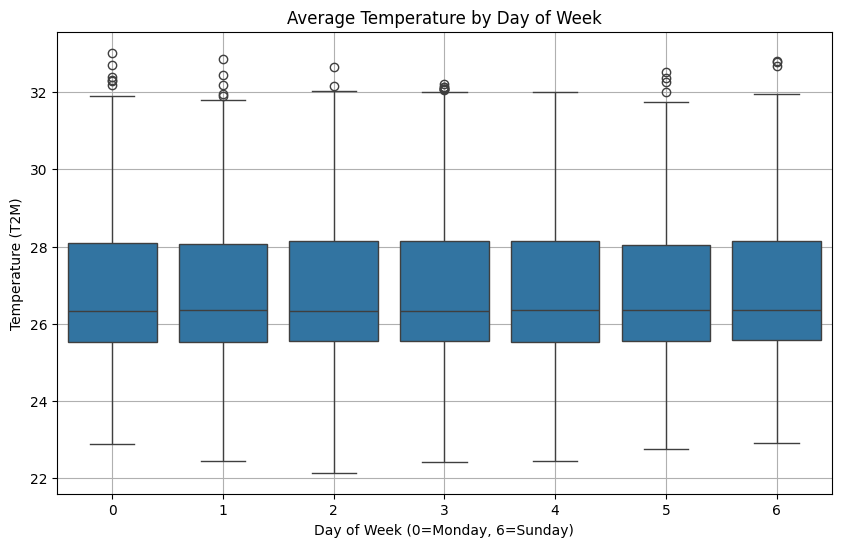

In [ ]:
# Average Temperature by Month
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.index.month, y=df['T2M'])
plt.title('Average Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Temperature (T2M)')
plt.grid(True)
plt.show()

# Average Temperature by Day of Week
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.index.dayofweek, y=df['T2M'])
plt.title('Average Temperature by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Temperature (T2M)')
plt.grid(True)
plt.show()

#First boxplot clearly illustrates a strong annual seasonality.
#Second boxplot typically reveals much less seasonality compared
#to the monthly view.

### Autocorrelation (ACF) and Partial Autocorrelation (PACF) Plots

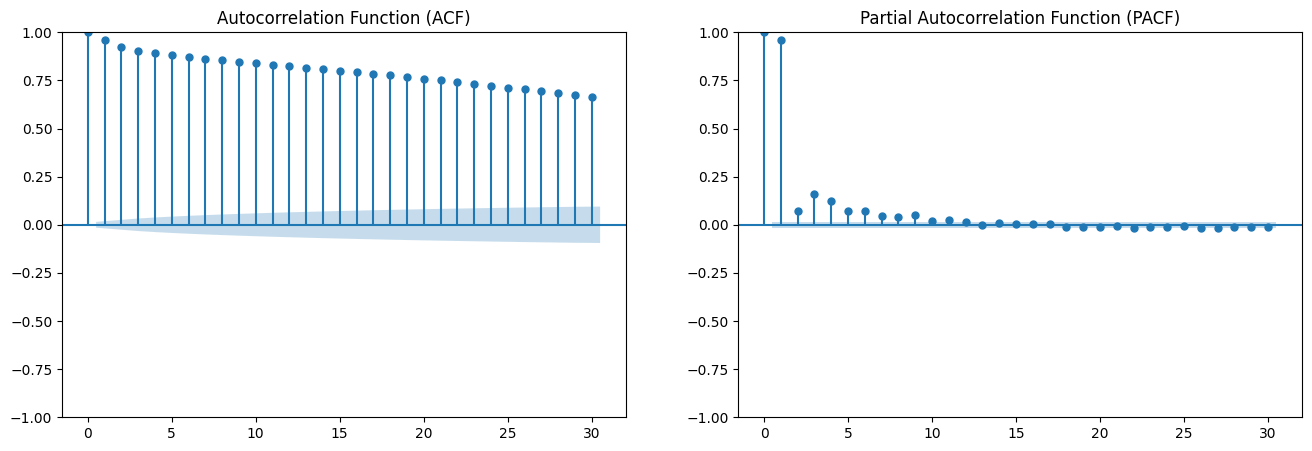

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['T2M'], lags=30, ax=axes[0], title='Autocorrelation Function (ACF)')
plot_pacf(df['T2M'], lags=30, ax=axes[1], title='Partial Autocorrelation Function (PACF)')
plt.show()

### Time Series Decomposition

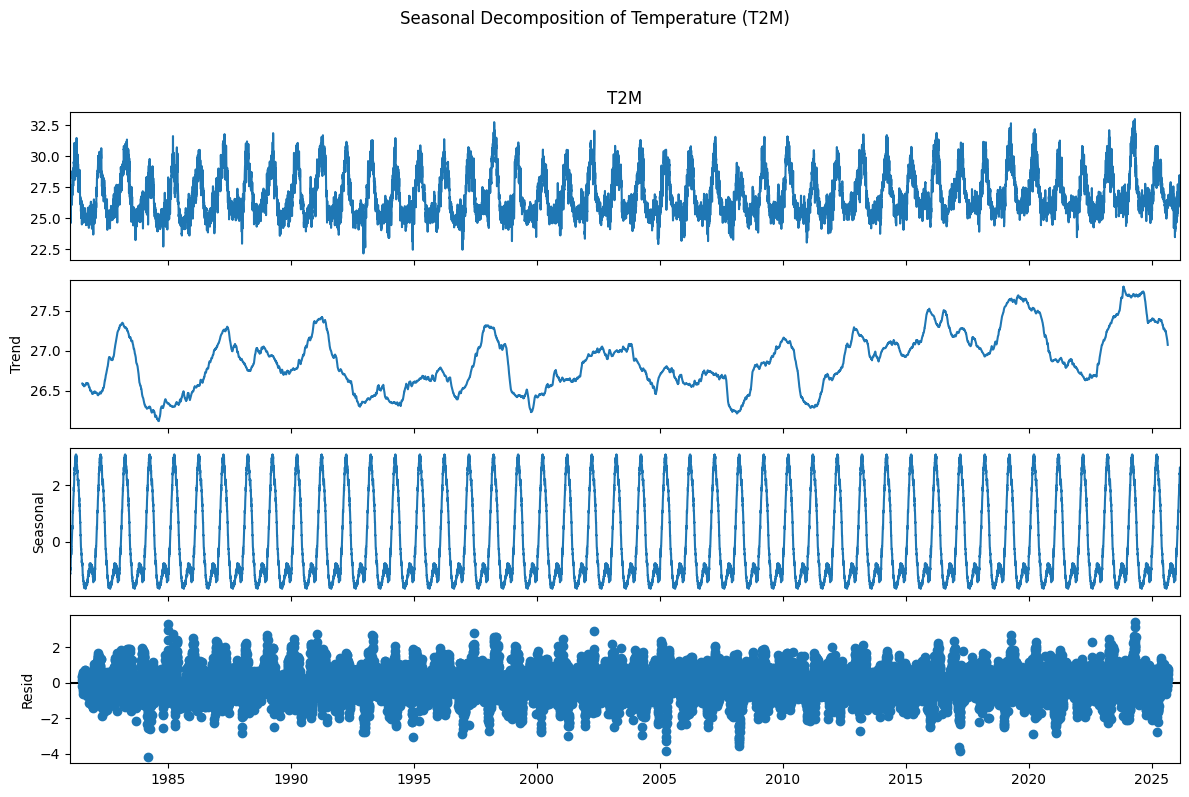

In [ ]:
# Perform seasonal decomposition
decomposition = seasonal_decompose(df['T2M'], model='additive', period=365) # Assuming yearly seasonality

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition of Temperature (T2M)', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

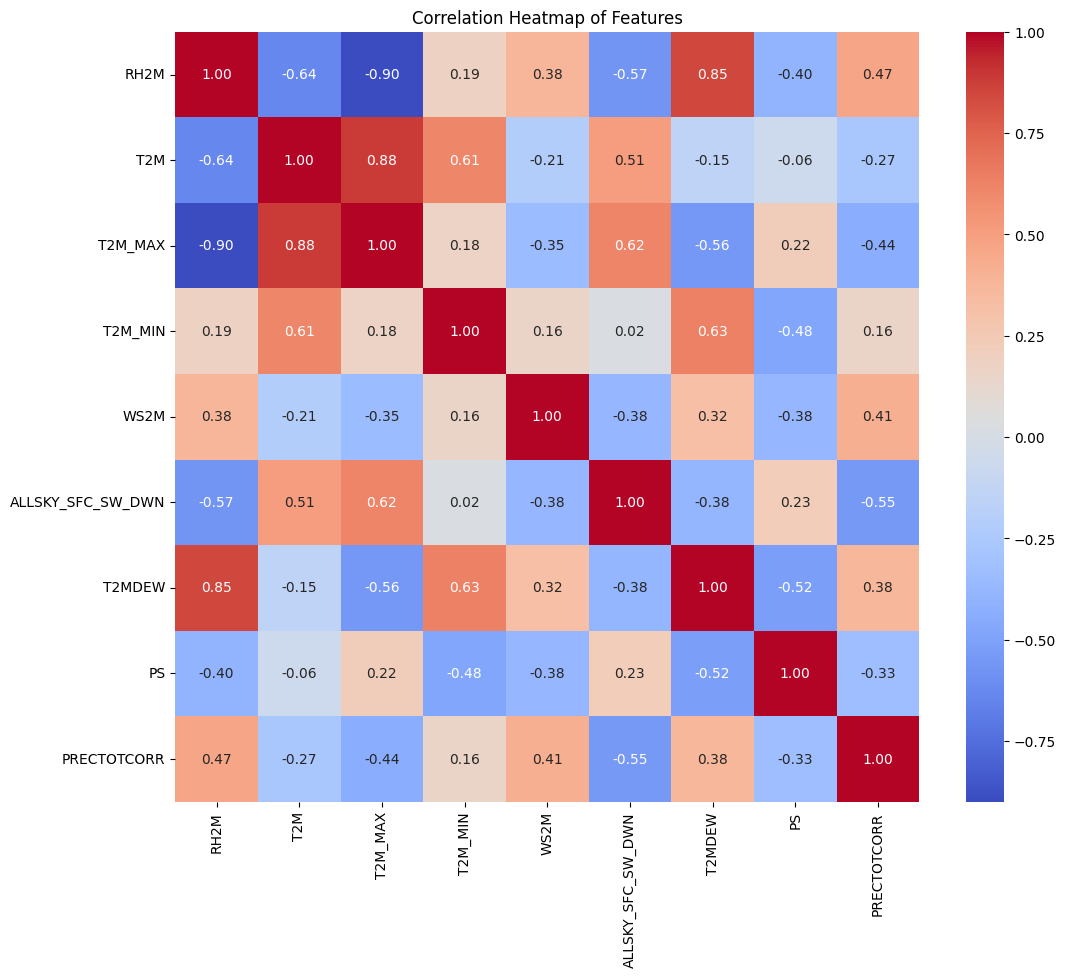

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

In [ ]:
df['temp_lag1'] = df['T2M'].shift(1)
df['temp_lag2'] = df['T2M'].shift(2)
df['temp_lag3'] = df['T2M'].shift(3)
# Rolling Features
df['temp_roll3'] = df['T2M'].rolling(3).mean()
df['temp_roll7'] = df['T2M'].rolling(7).mean()
# Date Features (Seasonality)
df['month'] = df.index.month
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek
df['week_of_year'] = df.index.isocalendar().week

In [ ]:
features = [
'T2M',
'RH2M',
'WS2M',
'PRECTOTCORR',
'temp_lag1',
'temp_lag2',
'temp_lag3',
'temp_roll3',
'temp_roll7',
'month',
'day',
'day_of_week',
'week_of_year'
]

df['target_temp'] = df['T2M'].shift(-1) #creating column which is the temp
                                        #shifted one day into the future.
                                        #this means the model will be trained to
                                        #predict tomorrows temp based on today's data



df.dropna(inplace=True)

X = df[features]
y = df['target_temp']

#not dropping T2M from features list b'coz in features it represents current day's
#temp, which is highly relevant predictor for tomorrow's temp(target temp).


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))
#The .values.reshape(-1,1) part is necessary because y
#is a pandas Series, and MinMaxScaler expects a 2D array (a column vector in this case).

In [ ]:
split = int(len(X_scaled)*0.8)

X_train = X_scaled[:split]
X_test = X_scaled[split:]

y_train = y_scaled[:split]
y_test = y_scaled[split:]

In [ ]:
#reshaping the input data in a 3D format(no: of samples, time steps,num of features )
#Here, X_train.shape[0] is the number of samples,
#1 represents a single time step (as we are predicting one step ahead),
# and X_train.shape[1] is the number of features.

X_train = X_train.reshape(X_train.shape[0],1,X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0],1,X_test.shape[1])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, input_shape=(1,X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(
optimizer='adam',
loss='mse'
)
#Adds the first layer, an LSTM layer with 64 memory units.
# The input_shape=(1, X_train.shape[2]) tells the model what the shape of its
# input data will be: 1 time step (since we reshaped X_train for one-step-ahead prediction)
#and X_train.shape[2] features per time step.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history=model.fit(
X_train,
y_train,
epochs=30,
batch_size=32,
validation_data=(X_test,y_test)
)

Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0147 - val_loss: 0.0026
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0036 - val_loss: 0.0024
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033 - val_loss: 0.0029
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0030 - val_loss: 0.0023
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0029 - val_loss: 0.0022
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 8/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 9/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 10/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 11/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 12/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

In [ ]:
pred_scaled = model.predict(X_test)

pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
def classify_weather(temp, rain):

    if rain > 5:
        return "Rainy"

    elif rain > 1:
        return "Cloudy"

    elif temp > 32:
        return "Hot"

    else:
        return "Pleasant"

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2:",r2_score(y_true,pred))
print("MAE:",mean_absolute_error(y_true,pred))
print("RMSE:",np.sqrt(mean_squared_error(y_true,pred)))

R2: 0.9095106475615163
MAE: 0.39940078406857316
RMSE: 0.5148991032007555


In [ ]:
def predict_tomorrow(today_input):

    global df

    today_df = pd.DataFrame([today_input])

    today_df.index = [df.index[-1] + pd.Timedelta(days=1)]

    temp_lag1 = df['T2M'].iloc[-1]
    temp_lag2 = df['T2M'].iloc[-2]
    temp_lag3 = df['T2M'].iloc[-3]

    temp_roll3 = df['T2M'].iloc[-3:].mean()
    temp_roll7 = df['T2M'].iloc[-7:].mean()

    today_df['temp_lag1'] = temp_lag1
    today_df['temp_lag2'] = temp_lag2
    today_df['temp_lag3'] = temp_lag3

    today_df['temp_roll3'] = temp_roll3
    today_df['temp_roll7'] = temp_roll7

    today_df['month'] = today_df.index.month
    today_df['day'] = today_df.index.day
    today_df['day_of_week'] = today_df.index.dayofweek
    today_df['week_of_year'] = today_df.index.isocalendar().week

    today_df = today_df[features]

    scaled = scaler_X.transform(today_df)

    scaled = scaled.reshape(1,1,scaled.shape[1])

    pred_scaled = model.predict(scaled)

    pred_temp = scaler_y.inverse_transform(pred_scaled)

    predicted_temperature = pred_temp[0][0]
    rain_for_classification = today_input['PRECTOTCORR']
    weather_classification = classify_weather(predicted_temperature, rain_for_classification)

    return predicted_temperature, weather_classification

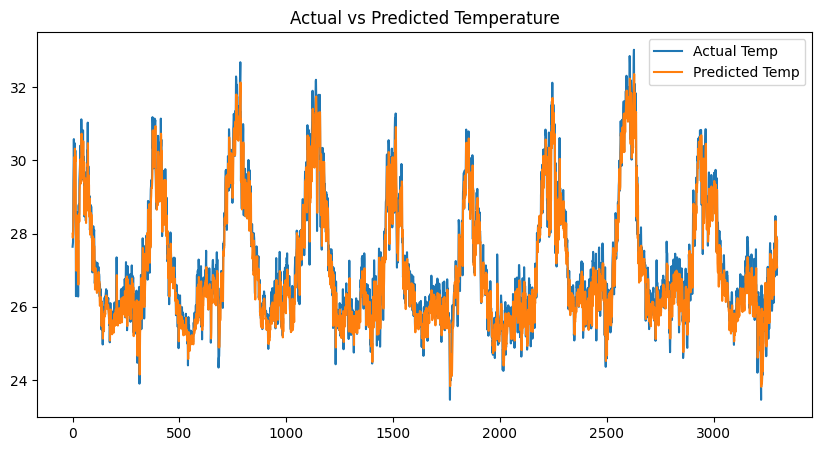

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_true, label="Actual Temp")
plt.plot(pred, label="Predicted Temp")

plt.legend()

plt.title("Actual vs Predicted Temperature")

plt.show()

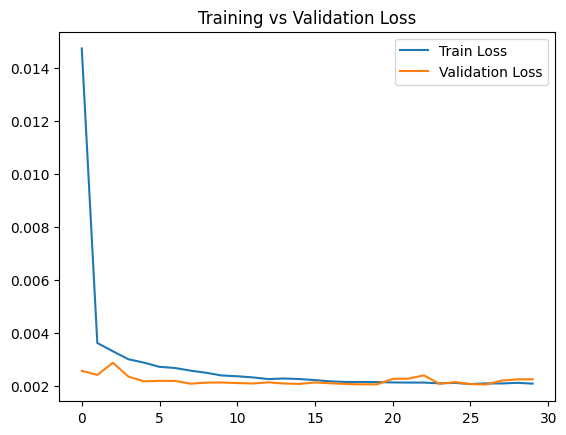

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train Loss','Validation Loss'])

plt.title("Training vs Validation Loss")

plt.show()

In [ ]:
today_weather = {

'T2M':32,
'RH2M':80,
'WS2M':17,
'PRECTOTCORR':0,
'PS':101.1

}

predicted_temp, weather_forecast = predict_tomorrow(today_weather)

print("Predicted Temperature for tomorrow:", predicted_temp)
print("Predicted Weather for tomorrow:", weather_forecast)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Temperature for tomorrow: 31.467983
Predicted Weather for tomorrow: Pleasant


In [ ]:
train_pred=model.predict(X_train)
test_pred=model.predict(X_test)
print("Train R2:", r2_score(y_train,train_pred))
print("Test R2:", r2_score(y_test,test_pred))

413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Train R2: 0.9235276490382636
Test R2: 0.9095106651772082


In [ ]:
pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.0 MB/s eta 0:00:00


In [ ]:
from keras_tuner import RandomSearch
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

# Define the input_shape explicitly using the shape of X_train
input_shape_for_tuner = (X_train.shape[1], X_train.shape[2])

def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('lstm_units', min_value=32, max_value=128, step=32),
                   input_shape=input_shape_for_tuner))
    model.add(Dropout(hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')
    return model

tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='lstm_tuning'
)

tuner.search(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"The best LSTM units are {best_hps.get('lstm_units')}")
print(f"The best dropout rate is {best_hps.get('dropout_rate')}")

Trial 10 Complete [00h 01m 01s]
val_loss: 0.0020239083096385

Best val_loss So Far: 0.0020239083096385
Total elapsed time: 00h 10m 05s
The best LSTM units are 96
The best dropout rate is 0.30000000000000004


In [ ]:
# Get the best model from the tuner
best_model = tuner.get_best_models(num_models=1)[0]

# Make predictions with the best model
pred_scaled_tuned = best_model.predict(X_test)

# Inverse transform the predictions and true values
pred_tuned = scaler_y.inverse_transform(pred_scaled_tuned)
y_true_tuned = scaler_y.inverse_transform(y_test)

# Calculate and print the R2 score
from sklearn.metrics import r2_score
print("R2 score after hyperparameter tuning:", r2_score(y_true_tuned, pred_tuned))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
R2 score after hyperparameter tuning: 0.9182285231249365


### Executing and Evaluating the Tuned Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Get the best hyperparameters
best_lstm_units = best_hps.get('lstm_units')
best_dropout_rate = best_hps.get('dropout_rate')

# Define the input_shape explicitly
input_shape_for_model = (X_train.shape[1], X_train.shape[2])

# Build the model with the best hyperparameters
tuned_model = Sequential()
tuned_model.add(LSTM(units=best_lstm_units, input_shape=input_shape_for_model))
tuned_model.add(Dropout(best_dropout_rate))
tuned_model.add(Dense(1))

tuned_model.compile(
    optimizer='adam',
    loss='mse'
)

tuned_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 96)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,337 (165.38 KB)

 Trainable params: 42,337 (165.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(f"Training model with {best_lstm_units} LSTM units and a dropout rate of {best_dropout_rate}")

history_tuned = tuned_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Training model with 96 LSTM units and a dropout rate of 0.30000000000000004
Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0082 - val_loss: 0.0025
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0035 - val_loss: 0.0028
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0032 - val_loss: 0.0022
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0029 - val_loss: 0.0023
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0028 - val_loss: 0.0024
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0027 - val_loss: 0.0023
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 8/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 9/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 10/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 11/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.

In [ ]:
import pandas as pd
import joblib
import os

# Create a directory to save the data if it doesn't exist
output_dir = 'model_artifacts'
os.makedirs(output_dir, exist_ok=True)

# Save the DataFrame to a pickle file
joblib.dump(df, os.path.join(output_dir, 'processed_weather_data.pkl'))
print(f"DataFrame 'df' saved to {os.path.join(output_dir, 'processed_weather_data.pkl')}")

DataFrame 'df' saved to model_artifacts/processed_weather_data.pkl


You can now load the processed DataFrame using the following code:

```python
import joblib
import os

loaded_df = joblib.load(os.path.join('model_artifacts', 'processed_weather_data.pkl'))
print("Processed DataFrame loaded successfully!")
loaded_df.head()
```

In [ ]:
# Calculate the split point (80% for training, 20% for testing)
split_point = int(len(X_scaled) * 0.8)

# Split X data into training and testing sets based on time order
X_train_ts = X_scaled[:split_point]
X_test_ts = X_scaled[split_point:]

# Split y data into training and testing sets based on time order
y_train_ts = y_scaled[:split_point]
y_test_ts = y_scaled[split_point:]

print(f"Total data points: {len(X_scaled)}")
print(f"Training data points: {len(X_train_ts)}")
print(f"Testing data points: {len(X_test_ts)}")

# You can also check the date ranges for clarity (assuming df is still available)
# Note: The original 'df' was dropped NaNs, so its index aligns with X/y after dropping
original_index = df.index
print(f"Training data date range: {original_index[:split_point].min()} to {original_index[:split_point].max()}")
print(f"Testing data date range: {original_index[split_point:].min()} to {original_index[split_point:].max()}")

Total data points: 16488
Training data points: 13190
Testing data points: 3298
Training data date range: 1981-01-07 00:00:00 to 2017-02-16 00:00:00
Testing data date range: 2017-02-17 00:00:00 to 2026-02-27 00:00:00


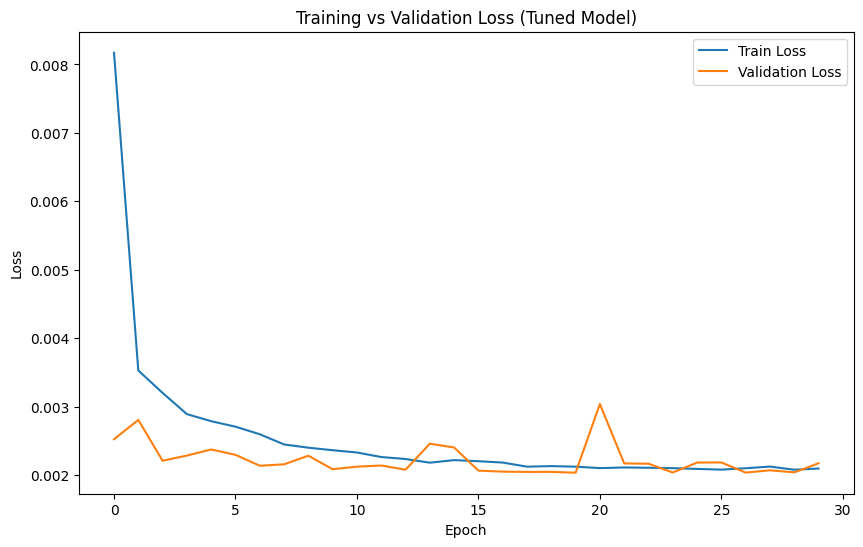

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss for the tuned model
plt.figure(figsize=(10, 6))
plt.plot(history_tuned.history['loss'], label='Train Loss')
plt.plot(history_tuned.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (Tuned Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions with the newly trained tuned model
pred_scaled_new_tuned = tuned_model.predict(X_test)

# Inverse transform the predictions and true values
pred_new_tuned = scaler_y.inverse_transform(pred_scaled_new_tuned)
y_true_new_tuned = scaler_y.inverse_transform(y_test)

print("Evaluation Metrics for the Newly Trained Tuned Model:")
print("R2:", r2_score(y_true_new_tuned, pred_new_tuned))
print("MAE:", mean_absolute_error(y_true_new_tuned, pred_new_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_true_new_tuned, pred_new_tuned)))

104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Evaluation Metrics for the Newly Trained Tuned Model:
R2: 0.9121738783415465
MAE: 0.3760435211940416
RMSE: 0.5072654083873845


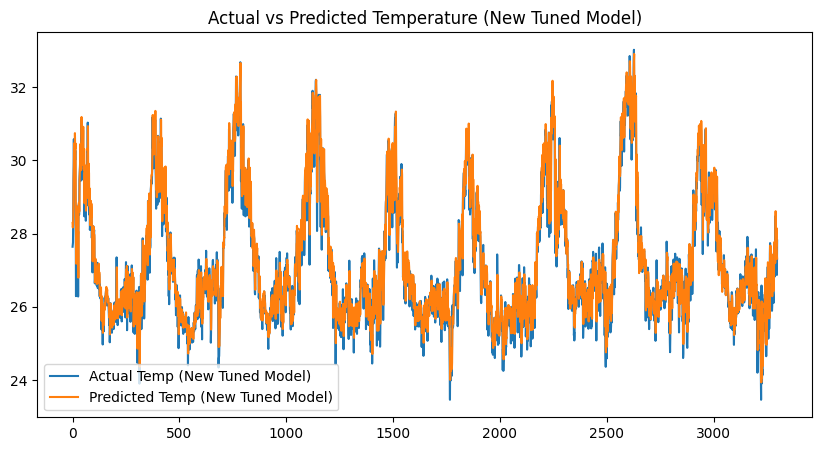

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_true_new_tuned, label="Actual Temp (New Tuned Model)")
plt.plot(pred_new_tuned, label="Predicted Temp (New Tuned Model)")

plt.legend()

plt.title("Actual vs Predicted Temperature (New Tuned Model)")

plt.show()

In [ ]:
print("R2 after hyperparameter tuning:", r2_score(y_true_tuned, pred_tuned))
print("MAE after hyperparameter tuning:", mean_absolute_error(y_true_tuned, pred_tuned))
print("RMSE after hyperparameter tuning:", np.sqrt(mean_squared_error(y_true_tuned, pred_tuned)))

R2 after hyperparameter tuning: 0.9182285231249365
MAE after hyperparameter tuning: 0.36795758027029873
RMSE after hyperparameter tuning: 0.48946801342905577


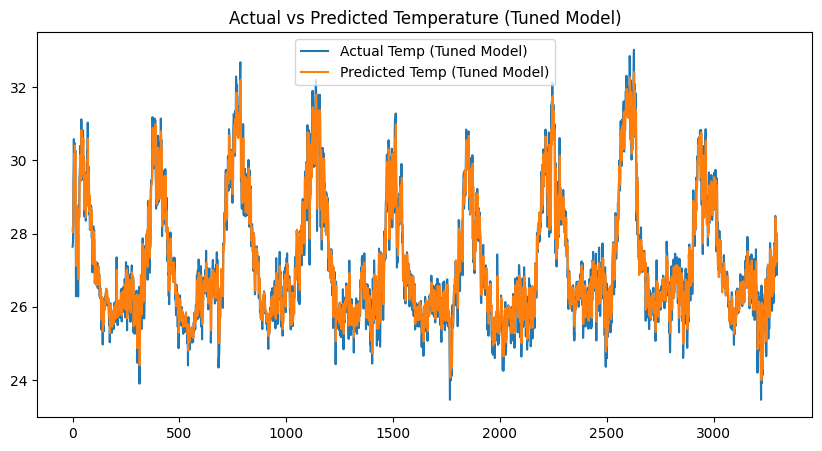

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_true_tuned, label="Actual Temp (Tuned Model)")
plt.plot(pred_tuned, label="Predicted Temp (Tuned Model)")

plt.legend()

plt.title("Actual vs Predicted Temperature (Tuned Model)")

plt.show()

In [ ]:
#Testing after hyperparametric tuning
def predict_tomorrow(today_input):

    global df, best_model # Add best_model to global scope

    today_df = pd.DataFrame([today_input])

    today_df.index = [df.index[-1] + pd.Timedelta(days=1)]

    temp_lag1 = df['T2M'].iloc[-1]
    temp_lag2 = df['T2M'].iloc[-2]
    temp_lag3 = df['T2M'].iloc[-3]

    temp_roll3 = df['T2M'].iloc[-3:].mean()
    temp_roll7 = df['T2M'].iloc[-7:].mean()

    today_df['temp_lag1'] = temp_lag1
    today_df['temp_lag2'] = temp_lag2
    today_df['temp_lag3'] = temp_lag3

    today_df['temp_roll3'] = temp_roll3
    today_df['temp_roll7'] = temp_roll7

    today_df['month'] = today_df.index.month
    today_df['day'] = today_df.index.day
    today_df['day_of_week'] = today_df.index.dayofweek
    today_df['week_of_year'] = today_df.index.isocalendar().week

    today_df = today_df[features]

    scaled = scaler_X.transform(today_df)

    scaled = scaled.reshape(1,1,scaled.shape[1])

    pred_scaled = best_model.predict(scaled) # Use best_model for prediction

    pred_temp = scaler_y.inverse_transform(pred_scaled)

    predicted_temperature = pred_temp[0][0]
    rain_for_classification = today_input['PRECTOTCORR']
    weather_classification = classify_weather(predicted_temperature, rain_for_classification)

    return predicted_temperature, weather_classification

In [ ]:
today_weather = {

'T2M':32,
'RH2M':80,
'WS2M':17,
'PRECTOTCORR':0,
'PS':101.1

}

predicted_temp, weather_forecast = predict_tomorrow(today_weather)

print("Predicted Temperature for tomorrow:", predicted_temp)
print("Predicted Weather for tomorrow:", weather_forecast)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Temperature for tomorrow: 31.376059
Predicted Weather for tomorrow: Pleasant


In [ ]:
import joblib
import os

# Create a directory to save the model and scalers
output_dir = 'model_artifacts'
os.makedirs(output_dir, exist_ok=True)

# Save the best model
best_model.save(os.path.join(output_dir, 'best_lstm_model.keras'))
print(f"Best model saved to {os.path.join(output_dir, 'best_lstm_model.keras')}")

# Save the X_scaler
joblib.dump(scaler_X, os.path.join(output_dir, 'scaler_X.pkl'))
print(f"scaler_X saved to {os.path.join(output_dir, 'scaler_X.pkl')}")

# Save the y_scaler
joblib.dump(scaler_y, os.path.join(output_dir, 'scaler_y.pkl'))
print(f"scaler_y saved to {os.path.join(output_dir, 'scaler_y.pkl')}")

Best model saved to model_artifacts/best_lstm_model.keras
scaler_X saved to model_artifacts/scaler_X.pkl
scaler_y saved to model_artifacts/scaler_y.pkl


You can now load these artifacts later if you need to make predictions or further analyze the model without retraining. For example:

```python
import joblib
from tensorflow.keras.models import load_model

# Load the model
loaded_model = load_model('model_artifacts/best_lstm_model.keras')

# Load the scalers
loaded_scaler_X = joblib.load('model_artifacts/scaler_X.pkl')
loaded_scaler_y = joblib.load('model_artifacts/scaler_y.pkl')

print("Model and scalers loaded successfully!")
```

In [ ]:
import shutil
from google.colab import files

# Zip model artifacts
shutil.make_archive('model_artifacts', 'zip', 'model_artifacts')

# Download everything
files.download('model_artifacts.zip')
files.download('Kerala_Weather.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
pip install streamlit tensorflow scikit-learn pandas numpy joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 33.7 MB/s eta 0:00:00


In [18]:
import streamlit as st
import tensorflow as tf
import numpy as np
import joblib
import pandas as pd
import os

# Define the features list used for model training
features = [
    'T2M',
    'RH2M',
    'WS2M',
    'PRECTOTCORR',
    'PS',
    'temp_lag1',
    'temp_lag2',
    'temp_lag3',
    'temp_roll3',
    'temp_roll7',
    'month',
    'day',
    'day_of_week',
    'week_of_year'
]

# Create a directory for model artifacts if it doesn't exist
output_dir = 'model_artifacts'
os.makedirs(output_dir, exist_ok=True)

# Load the pre-trained model and scalers
try:
    # Construct full paths to artifacts
    model_path = os.path.join(output_dir, 'best_lstm_model.keras')
    scaler_X_path = os.path.join(output_dir, 'scaler_X.pkl')
    scaler_y_path = os.path.join(output_dir, 'scaler_y.pkl')
    df_path = os.path.join(output_dir, 'processed_weather_data.pkl')

    best_model = tf.keras.models.load_model(model_path)
    scaler_X = joblib.load(scaler_X_path)
    scaler_y = joblib.load(scaler_y_path)
    df = joblib.load(df_path) # Load the historical DataFrame for feature engineering

    st.success("Model, scalers, and historical data loaded successfully!")
except Exception as e:
    st.error(f"Error loading model, scalers, or historical data. Make sure 'model_artifacts' directory and its contents are present: {e}")
    st.stop()

# Define the classify_weather function (from notebook cell ERxziDQjmS_u)
def classify_weather(temp, rain):
    if rain > 5:
        return "Rainy"
    elif rain > 1:
        return "Cloudy"
    elif temp > 32:
        return "Hot"
    else:
        return "Pleasant"

# Define the predict_tomorrow function (modified from notebook cell Z9VlPhH77ejb)
def predict_tomorrow_func(today_input):
    # This function uses the globally loaded `df`, `best_model`, `scaler_X`, `scaler_y`, and `features`
    global df, best_model, scaler_X, scaler_y, features

    today_df_single_row = pd.DataFrame([today_input])

    # The index must be a DatetimeIndex for date feature extraction
    # The new date is the day after the last date in the historical DataFrame
    new_date = df.index[-1] + pd.Timedelta(days=1)
    today_df_single_row.index = pd.to_datetime([new_date])

    # Calculate lagged and rolling features based on the end of the historical df
    temp_lag1 = df['T2M'].iloc[-1]
    temp_lag2 = df['T2M'].iloc[-2]
    temp_lag3 = df['T2M'].iloc[-3]

    temp_roll3 = df['T2M'].iloc[-3:].mean()
    temp_roll7 = df['T2M'].iloc[-7:].mean()

    today_df_single_row['temp_lag1'] = temp_lag1
    today_df_single_row['temp_lag2'] = temp_lag2
    today_df_single_row['temp_lag3'] = temp_lag3

    today_df_single_row['temp_roll3'] = temp_roll3
    today_df_single_row['temp_roll7'] = temp_roll7

    # Extract date features for the prediction day
    today_df_single_row['month'] = today_df_single_row.index.month
    today_df_single_row['day'] = today_df_single_row.index.day
    today_df_single_row['day_of_week'] = today_df_single_row.index.dayofweek
    # .isocalendar().week returns a Series, need to get the scalar value
    today_df_single_row['week_of_year'] = today_df_single_row.index.isocalendar().week.iloc[0]

    # Select only the features that the model was trained on
    today_df_processed_features = today_df_single_row[features]

    # Scale the features
    scaled_input = scaler_X.transform(today_df_processed_features)

    # Reshape for LSTM input (batch_size, timesteps, features)
    scaled_input_reshaped = scaled_input.reshape(1, 1, scaled_input.shape[1])

    # Make prediction
    pred_scaled = best_model.predict(scaled_input_reshaped)

    # Inverse transform the predicted temperature
    predicted_temperature = scaler_y.inverse_transform(pred_scaled)[0][0]

    # Get precipitation for weather classification from the user input
    rain_for_classification = today_input['PRECTOTCORR']
    weather_classification = classify_weather(predicted_temperature, rain_for_classification)

    return predicted_temperature, weather_classification

# Streamlit App Title
st.title('Next Day Temperature and Weather Prediction App')
st.write('Predicting next day temperature and weather classification based on current weather conditions.')

# Input features from user
st.sidebar.header('Input Current Weather Parameters')

def get_user_input_features():
    # These are the direct input features from the user for today's weather
    # which will be used along with historical data to engineer model features.
    t2m = st.sidebar.slider('Current Air Temperature (T2M, Celsius)', -10.0, 50.0, 25.0)
    rh2m = st.sidebar.slider('Current Relative Humidity (RH2M, %)', 0.0, 100.0, 70.0)
    ws2m = st.sidebar.slider('Current Wind Speed (WS2M, m/s)', 0.0, 30.0, 2.0)
    prectotcorr = st.sidebar.slider('Current Total Precipitation (PRECTOTCORR, mm)', 0.0, 200.0, 0.0)
    ps = st.sidebar.slider('Current Surface Pressure (PS, hPa)', 90.0, 110.0, 100.0)

    user_input_dict = {
        'T2M': t2m,
        'RH2M': rh2m,
        'WS2M': ws2m,
        'PRECTOTCORR': prectotcorr,
        'PS':ps
    }
    return user_input_dict

today_weather_input = get_user_input_features()

st.subheader('User Input Parameters for Today')
st.write(pd.DataFrame([today_weather_input]))

if st.button('Predict Next Day Temperature and Weather'):
    predicted_temperature, weather_forecast = predict_tomorrow_func(today_weather_input)

    st.subheader('Prediction for Tomorrow')
    st.metric("Predicted Temperature (Celsius)", f"{predicted_temperature:.2f} °C")
    st.write(f"**Predicted Weather:** {weather_forecast}")

    # Provide a bit more context based on the classification
    if weather_forecast == "Rainy":
        st.warning("Prediction: Expect significant rainfall tomorrow!")
    elif weather_forecast == "Cloudy":
        st.info("Prediction: Expect cloudy conditions with some light rain tomorrow.")
    elif weather_forecast == "Hot":
        st.error("Prediction: Expect hot weather tomorrow!")
    else: # Pleasant
        st.success("Prediction: Expect pleasant weather conditions tomorrow.")

# Instructions for running the app (remain the same)
# To run this app, save it as `app.py` and run `streamlit run app.py` in your terminal.
# Since we are in Colab, we will write this content to a file and provide instructions.

2026-03-18 11:56:23.181 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 11:56:23.183 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 11:56:23.188 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 11:56:23.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 11:56:23.193 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 11:56:23.199 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 11:56:23.205 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 11:56:23.207 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [19]:
import subprocess
import threading
from pyngrok import ngrok

def run_streamlit():
    process = subprocess.Popen(['streamlit', 'run', 'app.py'])
    process.wait()

streamlit_thread = threading.Thread(target=run_streamlit)
streamlit_thread.daemon = True
streamlit_thread.start()

import time
time.sleep(5)

public_url = ngrok.connect(8501)
print(f"Your Streamlit app is available at: {public_url}")

Your Streamlit app is available at: NgrokTunnel: "https://intellective-karlee-unequiangular.ngrok-free.dev" -> "http://localhost:8501"


In [16]:
import subprocess
import threading
from pyngrok import ngrok

def run_streamlit():
    process = subprocess.Popen(['streamlit', 'run', 'app.py'])
    process.wait()

streamlit_thread = threading.Thread(target=run_streamlit)
streamlit_thread.daemon = True
streamlit_thread.start()

import time
time.sleep(5)

public_url = ngrok.connect(8501)
print(f"Your Streamlit app is available at: {public_url}")

Your Streamlit app is available at: NgrokTunnel: "https://intellective-karlee-unequiangular.ngrok-free.dev" -> "http://localhost:8501"


In [3]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
import joblib
import pandas as pd
import os

# Define the features list used for model training
features = [
    'T2M',
    'RH2M',
    'WS2M',
    'PRECTOTCORR',
    'temp_lag1',
    'temp_lag2',
    'temp_lag3',
    'temp_roll3',
    'temp_roll7',
    'month',
    'day',
    'day_of_week',
    'week_of_year'
]

# Create a directory for model artifacts if it doesn't exist
output_dir = 'model_artifacts'
os.makedirs(output_dir, exist_ok=True)

# Load the pre-trained model and scalers
try:
    # Construct full paths to artifacts
    model_path = os.path.join(output_dir, 'best_lstm_model.keras')
    scaler_X_path = os.path.join(output_dir, 'scaler_X.pkl')
    scaler_y_path = os.path.join(output_dir, 'scaler_y.pkl')
    df_path = os.path.join(output_dir, 'processed_weather_data.pkl')

    best_model = tf.keras.models.load_model(model_path)
    scaler_X = joblib.load(scaler_X_path)
    scaler_y = joblib.load(scaler_y_path)
    df = joblib.load(df_path) # Load the historical DataFrame for feature engineering

    st.success("Model, scalers, and historical data loaded successfully!")
except Exception as e:
    st.error(f"Error loading model, scalers, or historical data. Make sure 'model_artifacts' directory and its contents are present: {e}")
    st.stop()

# Define the classify_weather function (from notebook cell ERxziDQjmS_u)
def classify_weather(temp, rain):
    if rain > 5:
        return "Rainy"
    elif rain > 1:
        return "Cloudy"
    elif temp > 32:
        return "Hot"
    else:
        return "Pleasant"

# Define the predict_tomorrow function (modified from notebook cell Z9VlPhH77ejb)
def predict_tomorrow_func(today_input):
    # This function uses the globally loaded `df`, `best_model`, `scaler_X`, `scaler_y`, and `features`
    global df, best_model, scaler_X, scaler_y, features

    today_df_single_row = pd.DataFrame([today_input])

    # The index must be a DatetimeIndex for date feature extraction
    # The new date is the day after the last date in the historical DataFrame
    new_date = df.index[-1] + pd.Timedelta(days=1)
    today_df_single_row.index = pd.to_datetime([new_date])

    # Calculate lagged and rolling features based on the end of the historical df
    temp_lag1 = df['T2M'].iloc[-1]
    temp_lag2 = df['T2M'].iloc[-2]
    temp_lag3 = df['T2M'].iloc[-3]

    temp_roll3 = df['T2M'].iloc[-3:].mean()
    temp_roll7 = df['T2M'].iloc[-7:].mean()

    today_df_single_row['temp_lag1'] = temp_lag1
    today_df_single_row['temp_lag2'] = temp_lag2
    today_df_single_row['temp_lag3'] = temp_lag3

    today_df_single_row['temp_roll3'] = temp_roll3
    today_df_single_row['temp_roll7'] = temp_roll7

    # Extract date features for the prediction day
    today_df_single_row['month'] = today_df_single_row.index.month
    today_df_single_row['day'] = today_df_single_row.index.day
    today_df_single_row['day_of_week'] = today_df_single_row.index.dayofweek
    # .isocalendar().week returns a Series, need to get the scalar value
    today_df_single_row['week_of_year'] = today_df_single_row.index.isocalendar().week.iloc[0]

    # Select only the features that the model was trained on
    today_df_processed_features = today_df_single_row[features]

    # Scale the features
    scaled_input = scaler_X.transform(today_df_processed_features)

    # Reshape for LSTM input (batch_size, timesteps, features)
    scaled_input_reshaped = scaled_input.reshape(1, 1, scaled_input.shape[1])

    # Make prediction
    pred_scaled = best_model.predict(scaled_input_reshaped)

    # Inverse transform the predicted temperature
    predicted_temperature = scaler_y.inverse_transform(pred_scaled)[0][0]

    # Get precipitation for weather classification from the user input
    rain_for_classification = today_input['PRECTOTCORR']
    weather_classification = classify_weather(predicted_temperature, rain_for_classification)

    return predicted_temperature, weather_classification

# Streamlit App Title
st.title('Next Day Temperature and Weather Prediction App')
st.write('Predicting next day temperature and weather classification based on current weather conditions.')

# Input features from user
st.sidebar.header('Input Current Weather Parameters')

def get_user_input_features():
    # These are the direct input features from the user for today's weather
    # which will be used along with historical data to engineer model features.
    t2m = st.sidebar.slider('Current Air Temperature (T2M, Celsius)', -10.0, 50.0, 25.0)
    rh2m = st.sidebar.slider('Current Relative Humidity (RH2M, %)', 0.0, 100.0, 70.0)
    ws2m = st.sidebar.slider('Current Wind Speed (WS2M, m/s)', 0.0, 30.0, 2.0)
    prectotcorr = st.sidebar.slider('Current Total Precipitation (PRECTOTCORR, mm)', 0.0, 200.0, 0.0)
    # ps=st.sidebar.slider('Current Surface Pressure (PS, hPa)',

    user_input_dict = {
        'T2M': t2m,
        'RH2M': rh2m,
        'WS2M': ws2m,
        'PRECTOTCORR': prectotcorr,
    }
    return user_input_dict

today_weather_input = get_user_input_features()

st.subheader('User Input Parameters for Today')
st.write(pd.DataFrame([today_weather_input]))

if st.button('Predict Next Day Temperature and Weather'):
    predicted_temperature, weather_forecast = predict_tomorrow_func(today_weather_input)

    st.subheader('Prediction for Tomorrow')
    st.metric("Predicted Temperature (Celsius)", f"{predicted_temperature:.2f} °C")
    st.write(f"**Predicted Weather:** {weather_forecast}")

    # Provide a bit more context based on the classification
    if weather_forecast == "Rainy":
        st.warning("Prediction: Expect significant rainfall tomorrow!")
    elif weather_forecast == "Cloudy":
        st.info("Prediction: Expect cloudy conditions with some light rain tomorrow.")
    elif weather_forecast == "Hot":
        st.error("Prediction: Expect hot weather tomorrow!")
    else: # Pleasant
        st.success("Prediction: Expect pleasant weather conditions tomorrow.")


Writing app.py


In [22]:
import subprocess
import threading
from pyngrok import ngrok

def run_streamlit():
    process = subprocess.Popen(['streamlit', 'run', 'app.py'])
    process.wait()

streamlit_thread = threading.Thread(target=run_streamlit)
streamlit_thread.daemon = True
streamlit_thread.start()

import time
time.sleep(5)



public_url = ngrok.connect(8501)
print(f"Your Streamlit app is available at: {public_url}")

Your Streamlit app is available at: NgrokTunnel: "https://intellective-karlee-unequiangular.ngrok-free.dev" -> "http://localhost:8501"


In [4]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.194.199.204:8501

  Stopping...
  Stopping...
Exception ignored in: <module 'threading' from '/usr/lib/python3.12/threading.py'>
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1594, in _shutdown
    atexit_call()
  File "/usr/lib/python3.12/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/usr/lib/python3.12/threading.py", line 1149, in join
    self._wait_for_tstate_lock()
  File "/usr/lib/python3.12/threading.py", line 1169, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/bootstrap.py", line 43, in signal_handler
    server.stop()
  File "/usr/local/li

In [20]:
with open('app.py', 'w') as f:
    f.write("""import streamlit as st
import tensorflow as tf
import numpy as np
import joblib
import pandas as pd
import os


# Define the features list used for model training
features = [
    'T2M',
    'RH2M',
    'WS2M',
    'PRECTOTCORR',
    'PS',
    'temp_lag1',
    'temp_lag2',
    'temp_lag3',
    'temp_roll3',
    'temp_roll7',
    'month',
    'day',
    'day_of_week',
    'week_of_year'
]

# Note: The model artifacts were saved directly in the root /content/ directory.
# Adjusting paths to load them directly.

# Load the pre-trained model and scalers
try:
    best_model = tf.keras.models.load_model('best_lstm_model.keras')
    scaler_X = joblib.load('scaler_X.pkl')
    scaler_y = joblib.load('scaler_y.pkl')
    df = joblib.load('processed_weather_data.pkl') # Load the historical DataFrame for feature engineering

    st.success("Model, scalers, and historical data loaded successfully!")
except Exception as e:
    st.error(f"Error loading model, scalers, or historical data. Please ensure 'best_lstm_model.keras', 'scaler_X.pkl', 'scaler_y.pkl', and 'processed_weather_data.pkl' are in the root directory: {e}")
    st.stop()

# Define the classify_weather function (from notebook cell ERxziDQjmS_u)
def classify_weather(temp, rain):
    if rain > 5:
        return "Rainy"
    elif rain > 1:
        return "Cloudy"
    elif temp > 32:
        return "Hot"
    else:
        return "Pleasant"

# Define the predict_tomorrow function (modified from notebook cell Z9VlPhH77ejb)
def predict_tomorrow_func(today_input):
    # This function uses the globally loaded `df`, `best_model`, `scaler_X`, `scaler_y`, and `features`
    global df, best_model, scaler_X, scaler_y, features

    today_df_single_row = pd.DataFrame([today_input])

    # The index must be a DatetimeIndex for date feature extraction
    # The new date is the day after the last date in the historical DataFrame
    new_date = df.index[-1] + pd.Timedelta(days=1)
    today_df_single_row.index = pd.to_datetime([new_date])

    # Calculate lagged and rolling features based on the end of the historical df
    temp_lag1 = df['T2M'].iloc[-1]
    temp_lag2 = df['T2M'].iloc[-2]
    temp_lag3 = df['T2M'].iloc[-3]

    temp_roll3 = df['T2M'].iloc[-3:].mean()
    temp_roll7 = df['T2M'].iloc[-7:].mean()

    today_df_single_row['temp_lag1'] = temp_lag1
    today_df_single_row['temp_lag2'] = temp_lag2
    today_df_single_row['temp_lag3'] = temp_lag3

    today_df_single_row['temp_roll3'] = temp_roll3
    today_df_single_row['temp_roll7'] = temp_roll7

    # Extract date features for the prediction day
    today_df_single_row['month'] = today_df_single_row.index.month
    today_df_single_row['day'] = today_df_single_row.index.day
    today_df_single_row['day_of_week'] = today_df_single_row.index.dayofweek
    # .isocalendar().week returns a Series, need to get the scalar value
    today_df_single_row['week_of_year'] = today_df_single_row.index.isocalendar().week.iloc[0]

    # Select only the features that the model was trained on
    today_df_processed_features = today_df_single_row[features]

    # Scale the features
    scaled_input = scaler_X.transform(today_df_processed_features)

    # Reshape for LSTM input (batch_size, timesteps, features)
    scaled_input_reshaped = scaled_input.reshape(1, 1, scaled_input.shape[1])

    # Make prediction
    pred_scaled = best_model.predict(scaled_input_reshaped)

    # Inverse transform the predicted temperature
    predicted_temperature = scaler_y.inverse_transform(pred_scaled)[0][0]

    # Get precipitation for weather classification from the user input
    rain_for_classification = today_input['PRECTOTCORR']
    weather_classification = classify_weather(predicted_temperature, rain_for_classification)

    return predicted_temperature, weather_classification

# Streamlit App Title
st.title('Next Day Temperature and Weather Prediction App')
st.write('Predicting next day temperature and weather classification based on current weather conditions.')

# Input features from user
st.sidebar.header('Input Current Weather Parameters')

def get_user_input_features():
    # These are the direct input features from the user for today's weather
    # which will be used along with historical data to engineer model features.
    t2m = st.sidebar.slider('Current Air Temperature (T2M, Celsius)', -10.0, 50.0, 25.0)
    rh2m = st.sidebar.slider('Current Relative Humidity (RH2M, %)', 0.0, 100.0, 70.0)
    ws2m = st.sidebar.slider('Current Wind Speed (WS2M, m/s)', 0.0, 30.0, 2.0)
    prectotcorr = st.sidebar.slider('Current Total Precipitation (PRECTOTCORR, mm)', 0.0, 200.0, 0.0)
    ps = st.sidebar.slider('Current Surface Pressure (PS, hPa)', 90.0, 110.0, 100.0)

    user_input_dict = {
        'T2M': t2m,
        'RH2M': rh2m,
        'WS2M': ws2m,
        'PRECTOTCORR': prectotcorr,
        'PS': ps
    }
    return user_input_dict

today_weather_input = get_user_input_features()

st.subheader('User Input Parameters for Today')
st.write(pd.DataFrame([today_weather_input]))

if st.button('Predict Next Day Temperature and Weather'):
    predicted_temperature, weather_forecast = predict_tomorrow_func(today_weather_input)

    st.subheader('Prediction for Tomorrow')
    st.metric("Predicted Temperature (Celsius)", f"{predicted_temperature:.2f} °C")
    st.write(f"**Predicted Weather:** {weather_forecast}")

    # Provide a bit more context based on the classification
    if weather_forecast == "Rainy":
        st.warning("Prediction: Expect significant rainfall tomorrow!")
    elif weather_forecast == "Cloudy":
        st.info("Prediction: Expect cloudy conditions with some light rain tomorrow.")
    elif weather_forecast == "Hot":
        st.error("Prediction: Expect hot weather tomorrow!")
    else: # Pleasant
        st.success("Prediction: Expect pleasant weather conditions tomorrow.")


""")

print("Streamlit app.py updated for temperature and weather prediction successfully!")

Streamlit app.py updated for temperature and weather prediction successfully!


In [6]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴

⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.194.199.204:8501

y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://cool-coins-fry.loca.lt
  Stopping...
^C


In [7]:
!pip install pyngrok -q

In [8]:
# Replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken
from pyngrok import ngrok

ngrok.set_auth_token("3B6mZsw4CwTJ1JQ6HWfjiN7oyA7_5614jsMmhwp5Stfzfr3cy")

In [12]:
import subprocess
import threading
from pyngrok import ngrok

def run_streamlit():
    process = subprocess.Popen(['streamlit', 'run', 'app.py'])
    process.wait()

streamlit_thread = threading.Thread(target=run_streamlit)
streamlit_thread.daemon = True
streamlit_thread.start()

import time
time.sleep(5)

public_url = ngrok.connect(8501)
print(f"Your Streamlit app is available at: {public_url}")

Your Streamlit app is available at: NgrokTunnel: "https://intellective-karlee-unequiangular.ngrok-free.dev" -> "http://localhost:8501"
